#**Netflix Movie Recommendation Engine**

 Environment setup

In [9]:
# Standard library
import os
import sys
import json
import numpy as np
import pandas as pd
from pathlib import Path

# Set project root BEFORE importing project modules
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Project modules
from src.inference.recommend import generate_genre_recommendations

print(f"Project root: {PROJECT_ROOT}")

Project root: d:\CODing\Netflix-movie-recommendation-engine-2.2\Netflix-movie-recommendation-engine


## Exploratory Data Analysis (EDA)

In this phase, the enriched Netflix dataset is analyzed to understand user rating behavior, movie popularity, genre distribution, and other insights before building recommendation models.

In [2]:
df = pd.read_parquet(PROJECT_ROOT / "data" / "netflix_final_dataset.parquet")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (24053764, 7)

Columns:
['Movie_ID', 'CustomerID', 'Rating', 'Date', 'Year', 'Title', 'Genre']

Data Types:
Movie_ID               int32
CustomerID             int32
Rating                  int8
Date          datetime64[ns]
Year                 float64
Title               category
Genre               category
dtype: object

Missing Values:
Movie_ID        0
CustomerID      0
Rating          0
Date            0
Year          189
Title           0
Genre           0
dtype: int64


In [3]:
df.describe(include="all")

,Movie_ID,CustomerID,Rating,Date,Year,Title,Genre
count,2.405376e+07,2.405376e+07,2.405376e+07,24053764,2.405358e+07,24053764,24053764
unique,NaN,NaN,NaN,NaN,NaN,4475,1115
top,NaN,NaN,NaN,NaN,NaN,Pirates of the Caribbean: The Curse of the Bla...,Drama
freq,NaN,NaN,NaN,NaN,NaN,193941,1252046
mean,2.308324e+03,1.322285e+06,3.599634e+00,2004-10-10 15:29:13.151649920,1.994406e+03,NaN,NaN
min,1.000000e+00,6.000000e+00,1.000000e+00,1999-11-11 00:00:00,1.915000e+03,NaN,NaN
25%,1.180000e+03,6.609270e+05,3.000000e+00,2004-04-30 00:00:00,1.991000e+03,NaN,NaN
50%,2.342000e+03,1.318602e+06,4.000000e+00,2005-01-19 00:00:00,1.999000e+03,NaN,NaN
75%,3.433000e+03,1.984358e+06,4.000000e+00,2005-06-30 00:00:00,2.003000e+03,NaN,NaN
max,4.499000e+03,2.649429e+06,5.000000e+00,2005-12-31 00:00:00,2.005000e+03,NaN,NaN


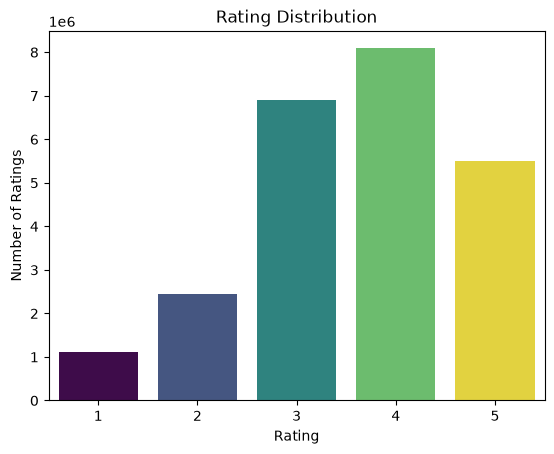

In [4]:
sns.countplot(
    x="Rating",
    data=df,
    hue="Rating",
    palette="viridis",
    legend=False
)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9328\3879344761.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Title")


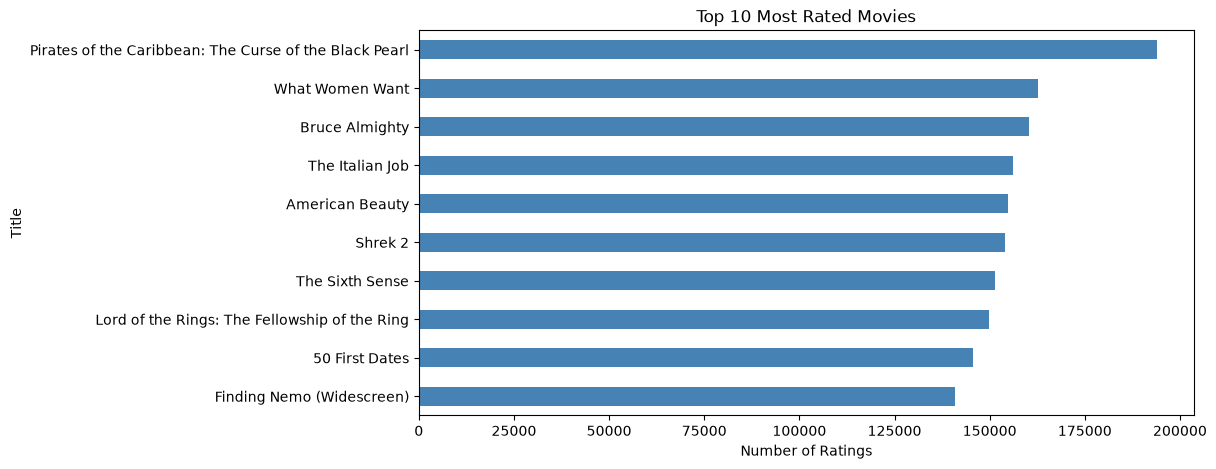

In [5]:
most_rated = (
    df.groupby("Title")
      .size()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

most_rated.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")

plt.show()

In [6]:
top_rated = df.groupby("Title").agg(
    Average_Rating = ("Rating", "mean"),
    Rating_count=("Rating", "count")
    )

top_rated = top_rated[
    top_rated["Rating_count"] >= 500
]

top_rated = top_rated.sort_values(
    "Average_Rating",
    ascending=False)
top_rated.head(10)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9328\3851318228.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_rated = df.groupby("Title").agg(


,Average_Rating,Rating_count
Title,,
Lost: Season 1,4.670989,7249
The Simpsons: Season 6,4.581296,8426
Inu-Yasha,4.554434,1883
Family Guy: Freakin' Sweet Collection,4.516007,10027
The West Wing: Season 3,4.473692,6633
Six Feet Under: Season 4,4.469693,11829
Samurai Champloo,4.467500,2000
Inu-Yasha: The Movie 3: Swords of an Honorable Ruler,4.464824,796
Stargate SG-1: Season 8,4.461921,1812


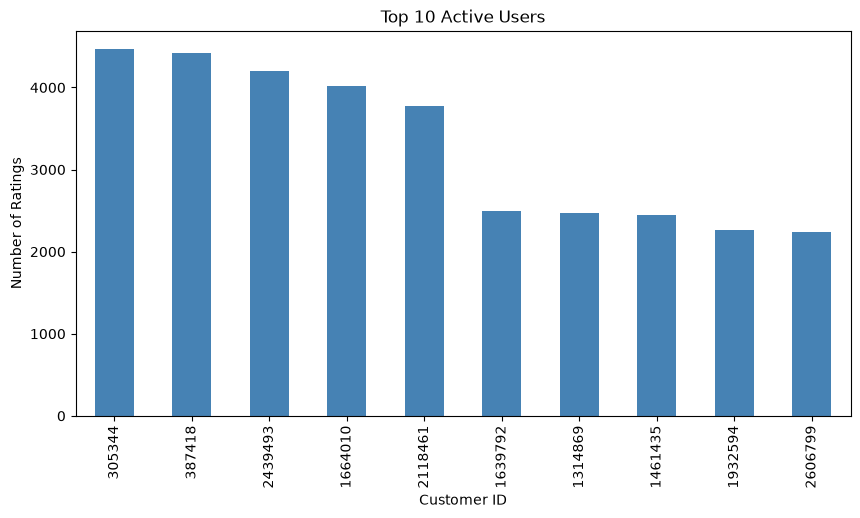

In [7]:
active_users=(
    df.groupby("CustomerID")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

active_users.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Active Users")
plt.xlabel("Customer ID")
plt.ylabel("Number of Ratings")

plt.show()

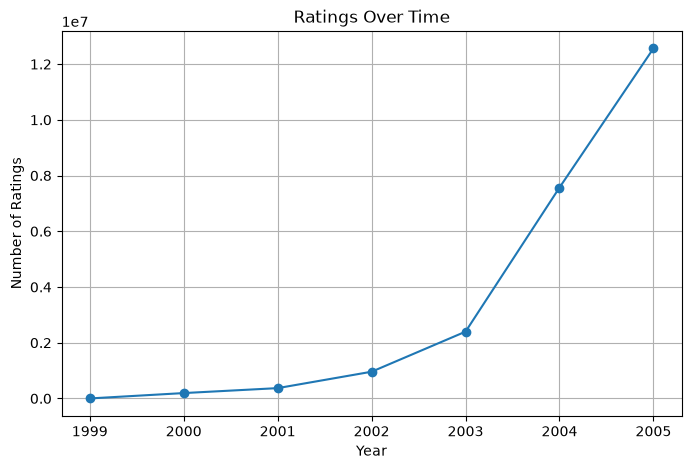

In [8]:
ratings_per_year = (
    df.groupby(df["Date"].dt.year)
      .size()
)

plt.figure(figsize=(8,5))

ratings_per_year.plot(
    marker="o"
)

plt.title("Ratings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")

plt.grid(True)

plt.show()

In [9]:
movie_stats = (
    df.groupby("Movie_ID", observed=True)["Rating"]
    .agg(rating_sum="sum", rating_count="count")
    .reset_index()
)

movie_genres = df[["Movie_ID", "Genre"]].drop_duplicates()
movie_genres["Genre"] = movie_genres["Genre"].str.split(", ")
movie_genres = movie_genres.explode("Genre")
movie_genres = movie_genres[
    movie_genres["Genre"].notna() & (movie_genres["Genre"] != "Unknown")
]

genre_movie_stats = movie_genres.merge(movie_stats, on="Movie_ID", how="left")
genre_counts = (
    genre_movie_stats.groupby("Genre", observed=True)["rating_count"]
    .sum()
    .sort_values(ascending=False)
)

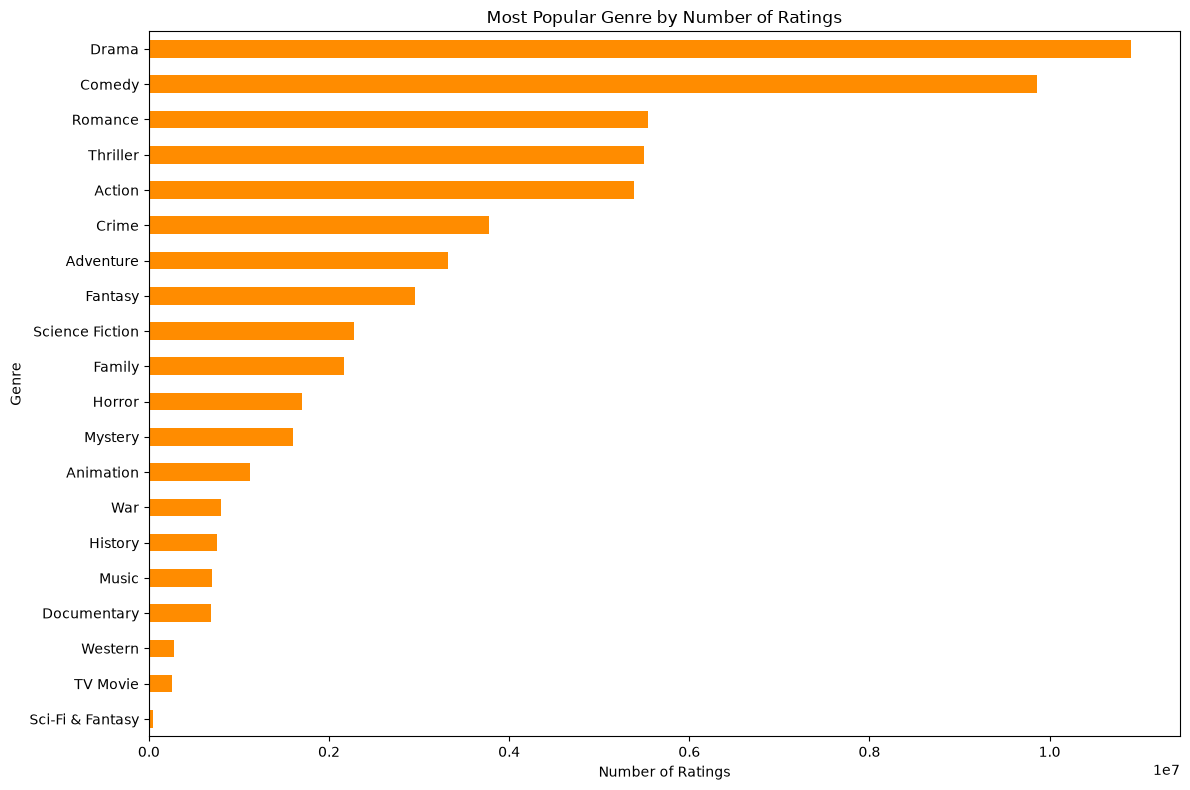

In [10]:
top_genres = genre_counts.head(20)

plt.figure(figsize=(12, 8))
top_genres.sort_values().plot(
    kind="barh",
    color="darkorange"
)

plt.title("Most Popular Genre by Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

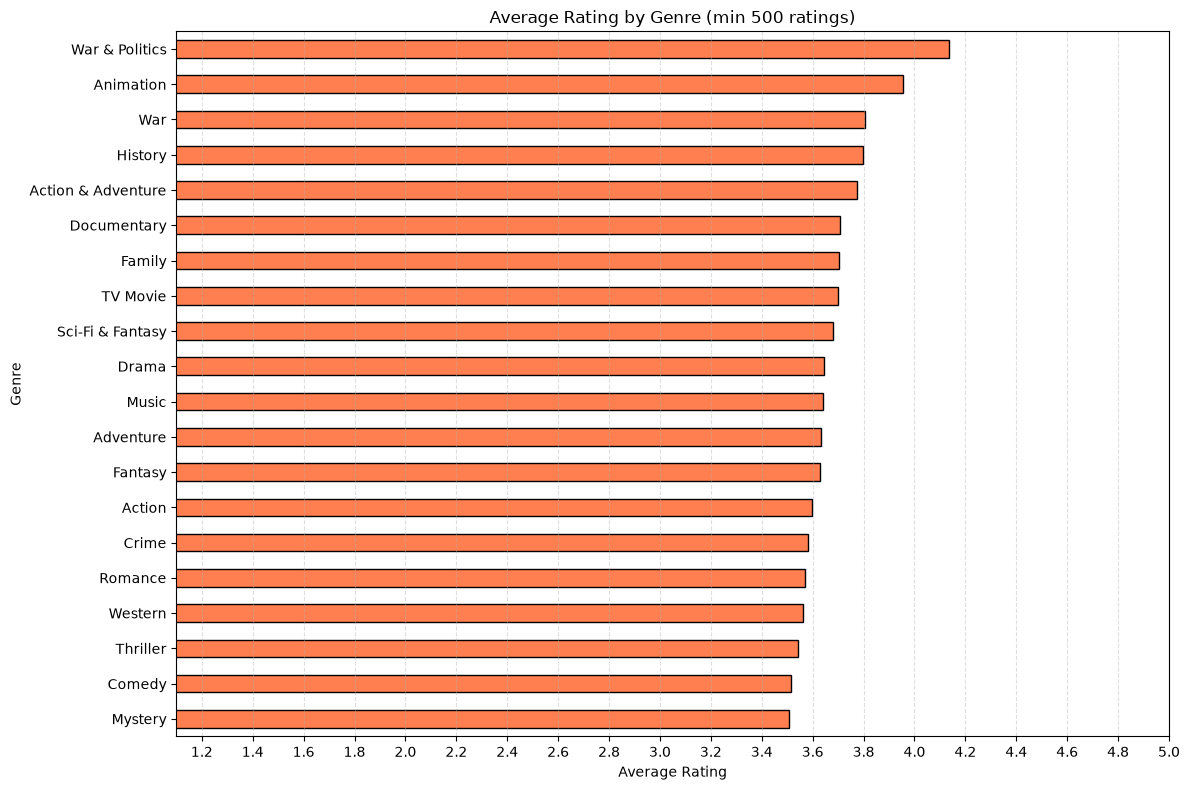

In [11]:
genre_avg = (
    genre_movie_stats.groupby("Genre", observed=True)
    .agg(
        Rating_Sum=("rating_sum", "sum"),
        Count=("rating_count", "sum")
    )
)
genre_avg["Avg_Rating"] = genre_avg["Rating_Sum"] / genre_avg["Count"]
genre_avg = (
    genre_avg[genre_avg["Count"] >= 500]
    .sort_values("Avg_Rating", ascending=False)
)

top_genres = genre_avg.head(20)

plt.figure(figsize=(12, 8))
ax = top_genres["Avg_Rating"].sort_values().plot(
    kind="barh",
    color="coral",
    edgecolor="black"
)

ticks = np.arange(1.2, 5.01, 0.2)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{x:.1f}" for x in ticks])
ax.set_xlim(1.1, 5.0)

ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_title("Average Rating by Genre (min 500 ratings)")
ax.set_xlabel("Average Rating")
ax.set_ylabel("Genre")

plt.tight_layout()
plt.show()

Top 5 Highest-Rated Genres (min. 500 ratings):
Genre
War & Politics        4.136876
Animation             3.954848
War                   3.806654
History               3.798711
Action & Adventure    3.775943

Bottom 5 Lowest-Rated Genres (min. 500 ratings):
Genre
Mystery            3.508251
Science Fiction    3.434164
Horror             3.396745
Kids               3.270153
Reality            3.222908


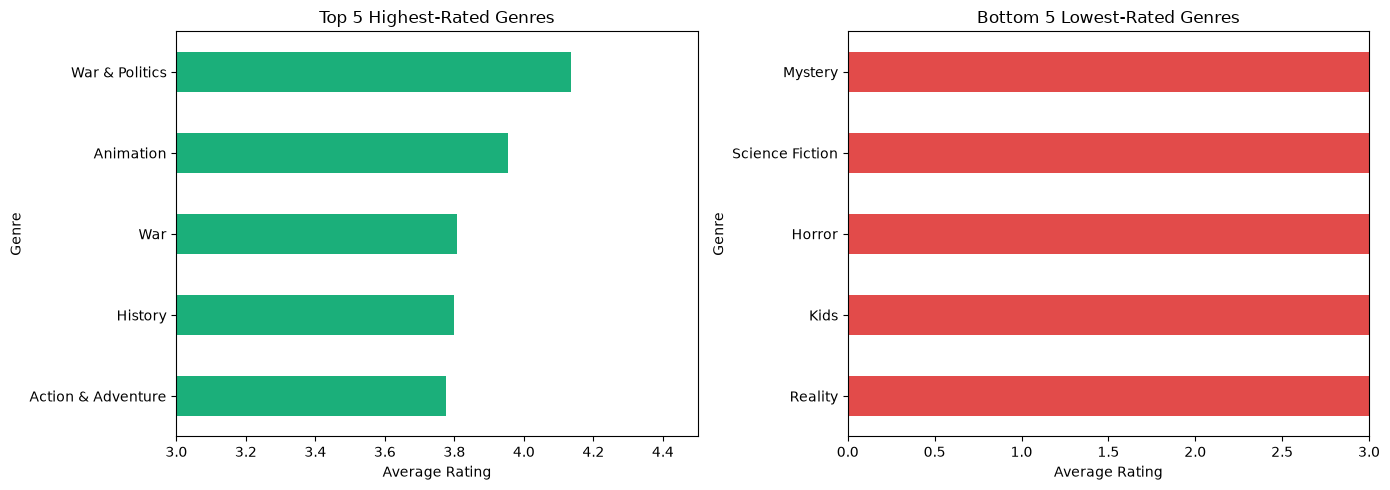

In [12]:
print("Top 5 Highest-Rated Genres (min. 500 ratings):")
print(genre_avg["Avg_Rating"].head(5).to_string())

print("\nBottom 5 Lowest-Rated Genres (min. 500 ratings):")
print(genre_avg["Avg_Rating"].tail(5).to_string())

#Objective 3 answer
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_avg["Avg_Rating"].head(5).sort_values().plot(
    kind="barh", ax=axes[0], color="#1baf7a"
)
axes[0].set_title("Top 5 Highest-Rated Genres")
axes[0].set_xlabel("Average Rating")
axes[0].set_xlim(3.0, 4.5)

genre_avg["Avg_Rating"].tail(5).sort_values().plot(
    kind="barh", ax=axes[1], color="#e24b4a"
)
axes[1].set_title("Bottom 5 Lowest-Rated Genres")
axes[1].set_xlabel("Average Rating")
axes[1].set_xlim(0.0, 3.0)

plt.tight_layout()
plt.show()

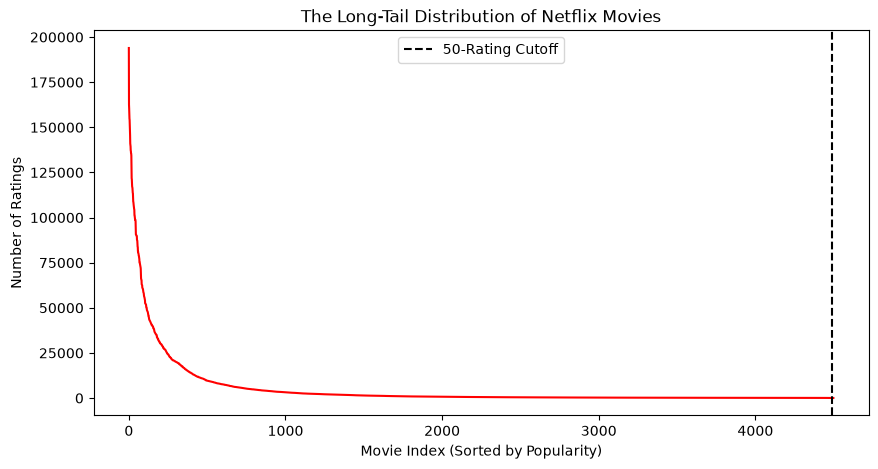

In [13]:
# Long-Tail Distribution of Movies

movie_counts = df.groupby("Movie_ID").size().sort_values(ascending=False)
active_movies = movie_counts[movie_counts >= 50]

plt.figure(figsize=(10, 5))

plt.plot(movie_counts.values, color="red")

plt.title("The Long-Tail Distribution of Netflix Movies")
plt.xlabel("Movie Index (Sorted by Popularity)")
plt.ylabel("Number of Ratings")

plt.axvline(
    x=len(active_movies),
    color="black",
    linestyle="--",
    label="50-Rating Cutoff"
)

plt.legend()
plt.show()

In [4]:
# Best-suited movie per genre for a given user

from src.config import TRAIN_DATA_PATH
from src.inference.recommend import generate_genre_recommendations

train_df = pd.read_parquet(
    TRAIN_DATA_PATH,
    columns=["CustomerID", "Movie_ID"]
)

sample_user = train_df["CustomerID"].value_counts().index[0]

status_msg, recs = generate_genre_recommendations(
    sample_user,
    top_n=1
)

print(status_msg)
display(recs)

Showing personalized results for user: 305344


,Genre,Movie Title,Predicted Rating
0,Action,Lord of the Rings: The Return of the King: Ext...,3.36


## Evaluation

In [ ]:
# Model Evaluation Data
from src.config import (
    TRAIN_DATA_PATH,
    VAL_DATA_PATH,
    TEST_DATA_PATH,
)

train_df = pd.read_parquet(TRAIN_DATA_PATH)
val_df = pd.read_parquet(VAL_DATA_PATH)
test_df = pd.read_parquet(TEST_DATA_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (18739840, 9)
Validation shape: (1250285, 9)
Test shape: (1020889, 9)


In [6]:
# Model Configuration

from src.config import (
    SVD_N_FACTORS,
    SVD_N_EPOCHS,
    SVD_LR_ALL,
    SVD_REG_ALL,
    ALS_FACTORS,
    ALS_ITERATIONS,
    ALS_REGULARIZATION,
)

model_config = pd.DataFrame({
    "Model": [
        "SVD",
        "ALS",
    ],
    "Configuration": [
        (
            f"factors={SVD_N_FACTORS}, "
            f"epochs={SVD_N_EPOCHS}, "
            f"lr={SVD_LR_ALL}, "
            f"reg={SVD_REG_ALL}"
        ),
        (
            f"factors={ALS_FACTORS}, "
            f"iterations={ALS_ITERATIONS}, "
            f"regularization={ALS_REGULARIZATION}"
        ),
    ],
})

display(model_config)

,Model,Configuration
0,SVD,"factors=50, epochs=20, lr=0.005, reg=0.04"
1,ALS,"factors=50, iterations=50, regularization=0.1"


In [10]:
# Rating Model Evaluation

from sklearn.metrics import mean_absolute_error

from src.models.popularity import get_or_train_popularity
from src.models.svd_model import get_or_train_svd


def calculate_metrics(actual, predicted):
    return {
        "RMSE": float(np.sqrt(np.mean((actual - predicted) ** 2))),
        "MAE": float(mean_absolute_error(actual, predicted)),
    }


# Load test data
test_eval = pd.read_parquet(
    TEST_DATA_PATH,
    columns=["CustomerID", "Movie_ID", "Rating"],
)

actual = test_eval["Rating"].to_numpy(dtype=float)


# Global Mean

popularity = get_or_train_popularity()

pred_global = np.full(
    len(test_eval),
    popularity["global_mean"],
)


# Popularity Rating

pred_popularity = (
    test_eval["Movie_ID"]
    .map(popularity["movie_avgs"])
    .fillna(popularity["global_mean"])
    .to_numpy()
)


# SVD

svd_model = get_or_train_svd()

pred_svd = np.empty(
    len(test_eval),
    dtype=np.float32,
)

for start in range(0, len(test_eval), 50_000):

    end = min(
        start + 50_000,
        len(test_eval),
    )

    chunk = test_eval.iloc[start:end]

    testset = list(
        zip(
            chunk["CustomerID"].astype(str),
            chunk["Movie_ID"].astype(str),
            chunk["Rating"],
        )
    )

    pred_svd[start:end] = [
        prediction.est
        for prediction in svd_model.test(testset)
    ]

# SVD + Popularity Ensemble

ensemble_weights = json.loads(
    (PROJECT_ROOT / "artifacts" / "ensemble_weights.json").read_text(
        encoding="utf-8"
    )
)

alpha = float(
    ensemble_weights["svd_alpha"]
)

pred_ensemble = np.clip(
    alpha * pred_svd
    + (1.0 - alpha) * pred_popularity,
    1.0,
    5.0,
)


# Build comparison table

rating_results = []

for model_name, predictions in [
    ("Global Mean", pred_global),
    ("Popularity Rating", pred_popularity),
    ("SVD", pred_svd),
    ("SVD + Popularity", pred_ensemble),
]:

    metrics = calculate_metrics(
        actual,
        predictions,
    )

    rating_results.append({
        "Model": model_name,
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
    })


rating_results = pd.DataFrame(
    rating_results
)

display(
    rating_results.style.format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
    })
)

Saved SVD model found at D:\CODing\Netflix-movie-recommendation-engine-2.2\Netflix-movie-recommendation-engine\artifacts\svd_model.pkl. Loading...
SVD model loaded successfully.


,Model,RMSE,MAE
0,Global Mean,1.0623,0.8960
1,Popularity Rating,1.0141,0.8148
2,SVD,0.9209,0.7113
3,SVD + Popularity,0.9189,0.7149


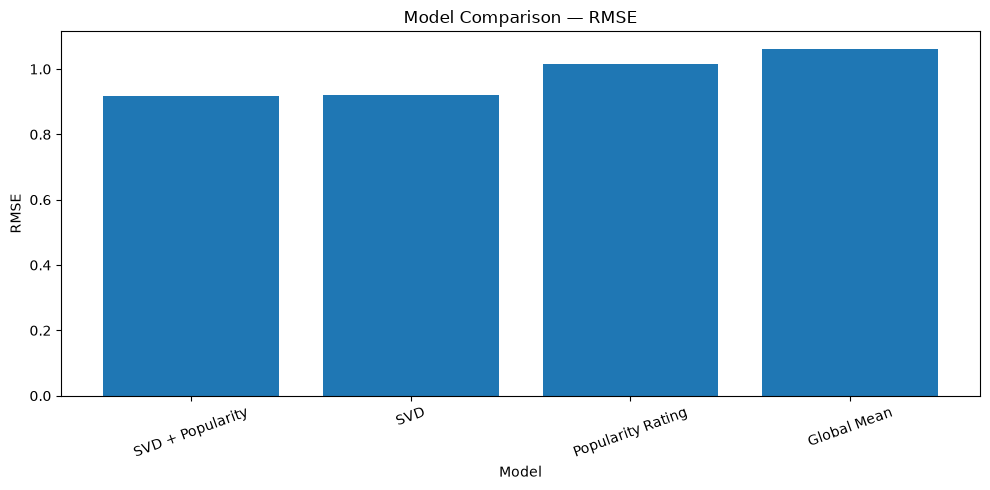

In [12]:
# RMSE Comparison

plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"],
)

plt.title("Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

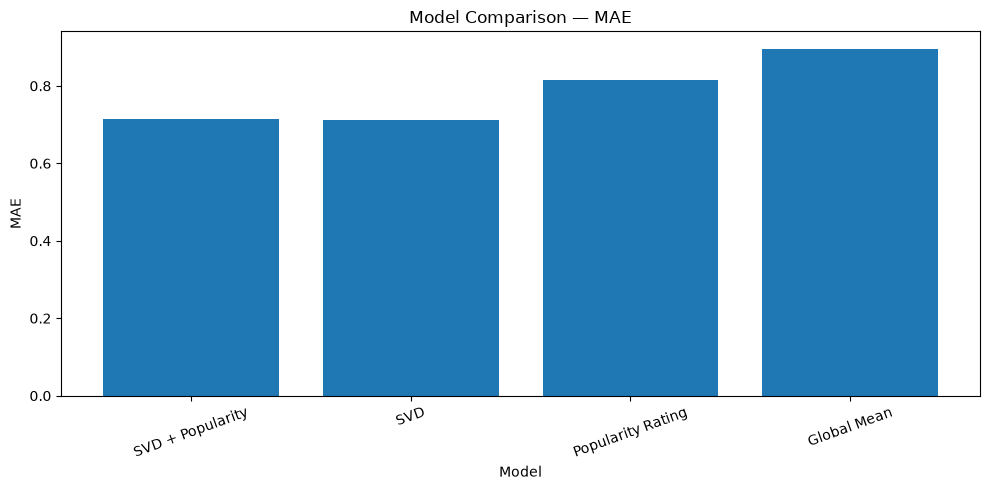

In [13]:
# MAE Comparison

plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"],
)

plt.title("Model Comparison — MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [14]:
# Ranking Evaluation

from src.evaluation.ranking import evaluate_top_n
from src.models.popularity import get_or_train_popularity
from src.models.svd_model import get_or_train_svd, predict_batch
from src.config import RANDOM_STATE

import json

popularity = get_or_train_popularity()
svd_model = get_or_train_svd()

candidate_movie_ids = train_df["Movie_ID"].drop_duplicates().tolist()

movies = pd.read_csv(
    PROJECT_ROOT / "data" / "movies_with_genres.csv",
    usecols=["Movie_ID", "Genre"],
)

genres = {
    row.Movie_ID: {
        genre.strip()
        for genre in str(row.Genre).split(",")
        if genre.strip() != "Unknown"
    }
    for row in movies.itertuples()
}

ensemble_weights = json.loads(
    (PROJECT_ROOT / "artifacts" / "ensemble_weights.json").read_text(
        encoding="utf-8"
    )
)

alpha = float(ensemble_weights["svd_alpha"])


def popularity_scorer(user_id, movie_ids):
    averages = popularity["movie_avgs"]
    global_mean = float(popularity["global_mean"])

    return np.asarray(
        [
            averages.get(movie_id, global_mean)
            for movie_id in movie_ids
        ],
        dtype=float,
    )


def svd_scorer(user_id, movie_ids):
    return predict_batch(
        svd_model,
        user_id,
        movie_ids,
    )


def ensemble_scorer(user_id, movie_ids):
    popularity_scores = popularity_scorer(
        user_id,
        movie_ids,
    )

    svd_scores = svd_scorer(
        user_id,
        movie_ids,
    )

    return np.clip(
        alpha * svd_scores
        + (1.0 - alpha) * popularity_scores,
        1.0,
        5.0,
    )


ranking_models = {
    "Popularity Rating": popularity_scorer,
    "SVD": svd_scorer,
    "SVD + Popularity Ensemble": ensemble_scorer,
}

ranking_results = []

for model_name, scorer in ranking_models.items():

    metrics = evaluate_top_n(
        test_df=test_df,
        train_df=train_df,
        candidate_movie_ids=candidate_movie_ids,
        scorer=scorer,
        k=10,
        random_state=RANDOM_STATE,
        genres=genres,
    )

    row = {
        "Model": model_name,
        **metrics,
    }

    ranking_results.append(row)


ranking_results = pd.DataFrame(ranking_results)

display(
    ranking_results.style.format({
        "precision@10": "{:.4f}",
        "recall@10": "{:.4f}",
        "ndcg@10": "{:.4f}",
        "catalog_coverage": "{:.4f}",
        "diversity": "{:.4f}",
    })
)

Saved SVD model found at D:\CODing\Netflix-movie-recommendation-engine-2.2\Netflix-movie-recommendation-engine\artifacts\svd_model.pkl. Loading...
SVD model loaded successfully.


,Model,precision@10,recall@10,ndcg@10,catalog_coverage,diversity
0,Popularity Rating,0.1252,0.3038,0.2828,0.0873,0.9203
1,SVD,0.1340,0.3340,0.2611,0.1751,0.9161
2,SVD + Popularity Ensemble,0.1378,0.3420,0.2710,0.1584,0.9170


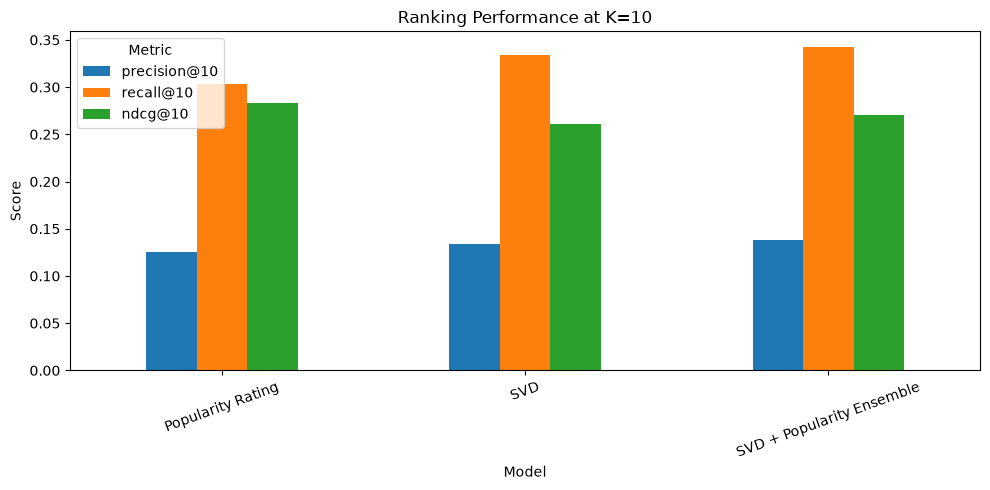

In [15]:
# Ranking Metrics Comparison

ranking_plot = ranking_results.set_index("Model")[
    [
        "precision@10",
        "recall@10",
        "ndcg@10",
    ]
]

ranking_plot.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Ranking Performance at K=10")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

## Project Summary & Business Answers

### Objective 1 — Most Popular and Most Liked Genre

- **Most popular by volume:** **Drama** — highest number of ratings across all users.

- **Most liked by average rating:** **War & Politics** — highest mean rating with a minimum of 500 ratings.

- These metrics can differ: a genre may receive high viewing volume while having a lower average rating. Both metrics provide useful perspectives for platform strategy.

### Objective 2 — Best-Suited Movie per Genre for a Given User

- **Hyperparameter Selection:** SVD hyperparameters were selected through prior offline experimentation. The selected configuration is **n_factors=50, n_epochs=20, lr_all=0.005, and reg_all=0.04**.

- The selected configuration is preserved in the project configuration and training pipeline.

- For each known user, predicted ratings are computed for unseen movies using the trained SVD model.

- The production recommendation path combines SVD predictions with popularity predictions using ensemble weights optimized on the validation split.

- The current validation-tuned ensemble uses approximately **87% SVD and 13% popularity**.

- The highest-scoring unseen movie within each genre is returned as the personalized recommendation.

- Unknown users receive popularity-based cold-start recommendations.

- Example output is shown above for the most active user in the training set.

### Objective 3 — Best and Worst Rated Genres

- **Best rated:** **War & Politics** with an average rating of **4.14** (minimum 500 ratings threshold applied).

- **Worst rated:** **Reality** with an average rating of **3.22**.

- A minimum rating count of 500 was enforced to reduce the influence of genres with very few ratings.

### Model Performance Summary

| Model | RMSE | MAE |
|---|---:|---:|
| Global Mean | 1.0623 | 0.8960 |
| Popularity Rating | 1.0141 | 0.8148 |
| **SVD** | **0.9209** | **0.7113** |
| **SVD + Popularity Ensemble** | **0.9189** | 0.7149 |

### Ranking Performance

| Model | Precision@10 | Recall@10 | NDCG@10 | Catalog Coverage | Diversity |
|---|---:|---:|---:|---:|---:|
| Popularity Rating | 0.1252 | 0.3038 | **0.2828** | 0.0873 | **0.9203** |
| SVD | 0.1340 | 0.3340 | 0.2611 | **0.1751** | 0.9161 |
| **SVD + Popularity Ensemble** | **0.1378** | **0.3420** | 0.2710 | 0.1584 | 0.9170 |

### Engineering Insights

- **SVD:** SVD provides the strongest standalone explicit-rating performance, achieving an RMSE of **0.9209** and the lowest MAE of **0.7113**.

- **SVD + Popularity Ensemble:** The ensemble achieves the **lowest RMSE (0.9189)**, improving on SVD's RMSE of 0.9209 by approximately **0.22%**. However, its MAE is slightly higher (**0.7149** vs **0.7113**). Therefore, the ensemble provides a marginal RMSE improvement rather than a major accuracy breakthrough.

- **Ranking Performance:** The ensemble provides the strongest top-10 recommendation performance, achieving the highest **Precision@10 (0.1378)** and **Recall@10 (0.3420)**. SVD provides higher catalog coverage (**0.1751**), while the popularity model achieves the highest diversity (**0.9203**).

- **Serving Architecture:** The production recommendation path uses the **SVD + Popularity ensemble** for known users. The optimized ensemble weights are loaded from `ensemble_weights.json` rather than recomputed during API startup. Unknown users use the popularity model as a cold-start fallback.

- **Evaluation Scope:** The reported RMSE and MAE are calculated on the held-out test split and primarily represent **warm-start performance**. Cold-start recommendation quality is handled separately through the popularity fallback and is not represented by these rating metrics.

- **Model Selection:** SVD is the strongest standalone explicit-rating model, while the **SVD + Popularity ensemble is used in production** because it provides the lowest observed RMSE and the strongest Precision@10 and Recall@10. The improvement is modest and should not be presented as a major accuracy breakthrough.